In [1]:
%matplotlib inline 
import matplotlib.pyplot as plt 
import numpy as np 
from lightning_scripts.jsinV3DataLoader_precombined_batched import jsinV3_precombined_all_signals
from robustness.audio_functions.audio_input_representations import AUDIO_INPUT_REPRESENTATIONS
import robustness.audio_functions.audio_transforms as at 
import yaml
from pathlib import Path

from IPython.display import display, Audio

In [4]:
out_dir = Path('talk_figs/simoncelli_group_07_30_2025')
outfig_dir = out_dir / 'figs'
outfig_dir.mkdir(parents=True, exist_ok=True)
outwav_dir  = out_dir / 'audio_egs'
outwav_dir.mkdir(parents=True, exist_ok=True)


In [5]:
val_dataset = jsinV3_precombined_all_signals(root="/mnt/ceph/users/jfeather/data/training_datasets_audio/JSIN_all_v3/subsets/",
                                                 train=False,
                                                 transform=None,
                                                 batch_size=1,
                                                 eval_max=5)

In [6]:
## Get cochleagram 
config_path = Path("model_configs/supervised_models/kell2018_word_speaker_audioset_MatchedDataset_LARS.yaml")
config = yaml.load(open(config_path, 'r'), Loader=yaml.FullLoader)


audio_config = AUDIO_INPUT_REPRESENTATIONS[config['audio_rep']['name']]
audio_rep = at.AudioToAudioRepresentation(**audio_config)

In [7]:
transforms = at.AudioCompose([
                    at.AudioToTensor(),
                    at.CombineWithRandomDBSNR(low_snr=0,
                                            high_snr=0),
                    at.RMSNormalizeForegroundAndBackground(rms_level=0.02),
                    at.UnsqueezeAudio(dim=0) # dim=0 here so batches of audio from dataloader will be (Batch, 1, Time)
                ])
speech, noise, _ = val_dataset[1]
mixture, _ = transforms(speech.squeeze(), noise.squeeze())
speech, _ = transforms(speech.squeeze(), None)
noise, _ = transforms(noise.squeeze(), None)

In [8]:
speech

tensor([[-0.0203, -0.0198, -0.0035,  ..., -0.0012, -0.0010, -0.0009]])

In [9]:
## Save out audio examples 

import soundfile as sf

sf.write(outwav_dir/"speech1.wav", speech.numpy().squeeze(), samplerate=20000)
sf.write(outwav_dir/"noise1.wav", noise.numpy().squeeze(), samplerate=20000)
sf.write(outwav_dir/"speech1_noise1_mix.wav", mixture.numpy().squeeze(), samplerate=20000)

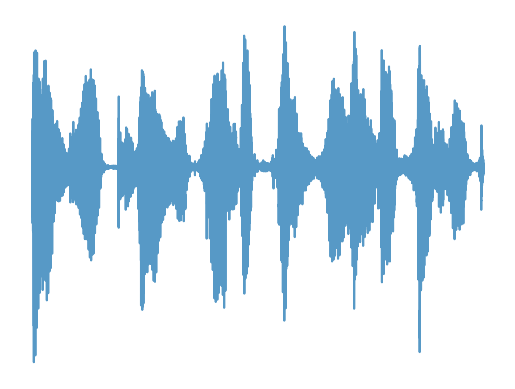

In [10]:
plt.plot(speech.squeeze(), alpha=0.75)
plt.axis('off')
plt.savefig(outfig_dir/'speech_wav_eg.png', transparent=True, dpi=500, bbox_inches='tight')


In [11]:
Audio(speech, rate=20_000)


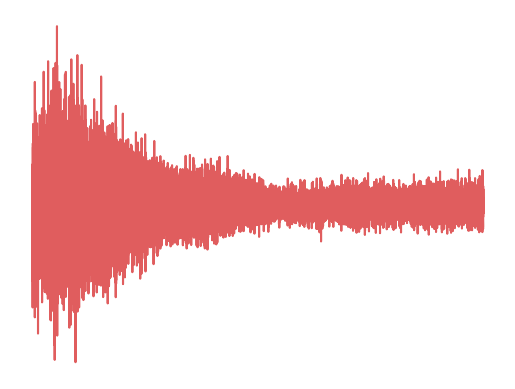

In [12]:
plt.plot(noise.squeeze(), 'tab:red', alpha=0.75)
plt.axis('off')
plt.savefig(outfig_dir/'noise_wav_eg.png', transparent=True,dpi=500,  bbox_inches='tight')


In [13]:
Audio(noise, rate=20_000)

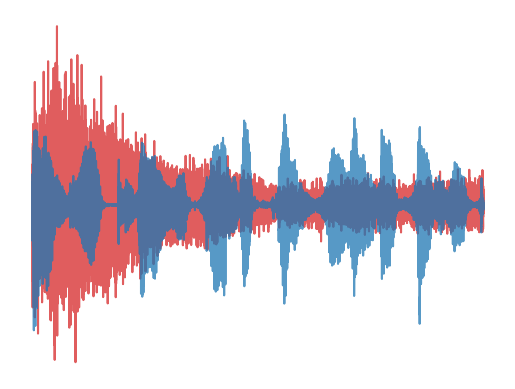

In [14]:
plt.plot(noise.squeeze(),'tab:red', alpha=0.75)
plt.plot(speech.squeeze(), alpha=0.75)
plt.axis('off')
plt.savefig(outfig_dir/'mix_wav_eg.png', transparent=True, dpi=500, bbox_inches='tight')


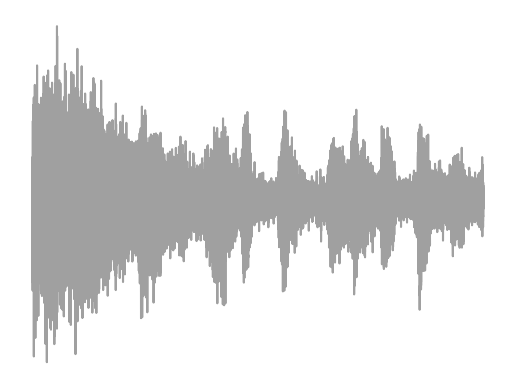

In [15]:
plt.plot(mixture.squeeze(),'grey', alpha=0.75)
plt.axis('off')
plt.savefig(outfig_dir/'mix_wav_eg_grey.png', transparent=True, dpi=500, bbox_inches='tight')


In [16]:
speech_coch, _ = audio_rep(speech, None)
noise_coch, _ = audio_rep(noise, None)
mixture_coch, _ = audio_rep(mixture, None)

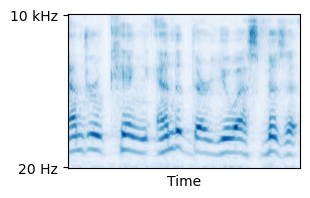

In [17]:
coch_size = (3,2)

speech_coch

plt.figure(figsize=coch_size)
plt.imshow(speech_coch.squeeze().numpy(), aspect='auto', origin='lower', cmap='Blues');
# plt.ylabel('Frequency')
plt.xlabel('Time')
plt.xticks([])
plt.yticks([1,210], ['20 Hz', '10 kHz'])
plt.savefig(outfig_dir/'speecH_coch_eg.png', transparent=True,dpi=500,  bbox_inches='tight')


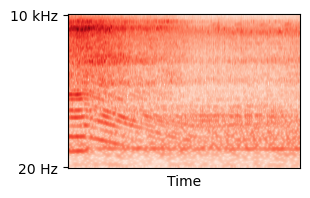

In [18]:
coch_size = (3,2)

speech_coch

plt.figure(figsize=coch_size)
plt.imshow(noise_coch.squeeze().numpy(), aspect='auto', origin='lower', cmap='Reds');
# plt.ylabel('Frequency')
plt.xlabel('Time')
plt.xticks([])
plt.yticks([1,210], ['20 Hz', '10 kHz'])
plt.savefig(outfig_dir/'noise_coch_eg.png', transparent=True, dpi=500, bbox_inches='tight')


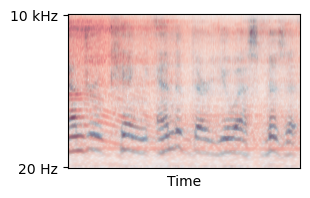

In [19]:
coch_size = (3,2)

speech_coch

plt.figure(figsize=coch_size)
plt.imshow(noise_coch.squeeze().numpy(), aspect='auto', origin='lower', cmap='Reds');
plt.imshow(speech_coch.squeeze().numpy(), aspect='auto', origin='lower', cmap='Blues', alpha=0.5);

# plt.ylabel('Frequency')
plt.xlabel('Time')
plt.xticks([])
plt.yticks([1,210], ['20 Hz', '10 kHz'])
plt.savefig(outfig_dir/'mix_coch.png', transparent=True, dpi=500, bbox_inches='tight')


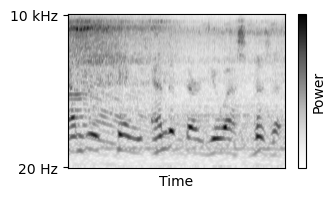

In [34]:
coch_size = (3.5,2)



plt.figure(figsize=coch_size)
im = plt.imshow(mixture_coch.squeeze().numpy(), aspect='auto', origin='lower', cmap='Greys');
# plt.ylabel('Frequency')
plt.xlabel('Time')
plt.xticks([])
plt.yticks([1,210], ['20 Hz', '10 kHz'])
cbar = plt.colorbar()
cbar.set_ticklabels([])
cbar.set_ticks([])
cbar.set_label('Power')

plt.savefig(outfig_dir/'mix_grey_coch_eg.png', transparent=True, dpi=500, bbox_inches='tight')


In [26]:
speech2.shape

(10001, 40000)

In [35]:

speech2, noise2, _ = val_dataset[2]
speech2 = np.pad(speech2[:,10000:], ((0,0), (0,10000)), mode='constant')
mixture2, _ = transforms(speech2.squeeze(), noise2.squeeze())
speech2, _ = transforms(speech2.squeeze(), None)
noise2, _ = transforms(noise2.squeeze(), None)



In [46]:

sf.write(outwav_dir/"speech2.wav", speech2.numpy().squeeze(), samplerate=20000)
sf.write(outwav_dir/"noise2.wav", noise2.numpy().squeeze(), samplerate=20000)
sf.write(outwav_dir/"speech2_noise2_mix.wav", mixture2.numpy().squeeze(), samplerate=20000)

In [50]:
#### Make paired mixture audio 

speech1_noise2_mix, _ = transforms(speech.numpy().squeeze(), noise2.numpy().squeeze())
speech2_noise1_mix, _ = transforms(speech2.numpy().squeeze(), noise.numpy().squeeze())

In [51]:

sf.write(outwav_dir/"speech1_noise2_mix.wav", speech1_noise2_mix.numpy().squeeze(), samplerate=20000)
sf.write(outwav_dir/"speech2_noise1_mix.wav", speech2_noise1_mix.numpy().squeeze(), samplerate=20000)


In [41]:
speech2_coch, _ = audio_rep(speech2, None)
noise2_coch, _ = audio_rep(noise2, None)
mixture2_coch, _ = audio_rep(mixture2, None)

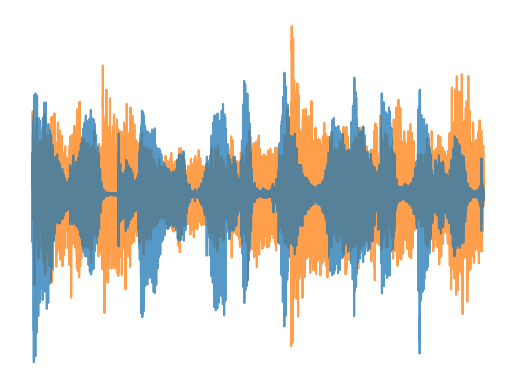

In [57]:
plt.plot(noise2.squeeze(),'tab:orange', alpha=0.75)
plt.plot(speech.squeeze(), alpha=0.75)
plt.axis('off')
plt.savefig(outfig_dir/'mix_wav_eg2.png', transparent=True, dpi=500, bbox_inches='tight')


([<matplotlib.axis.YTick at 0x15542f1291c0>,
 [Text(0, 1, '20 Hz'), Text(0, 210, '10 kHz')])

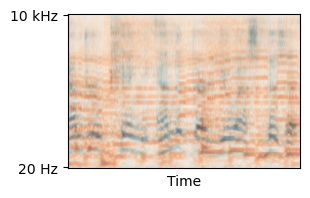

In [58]:
coch_size = (3,2)

speech_coch

plt.figure(figsize=coch_size)
plt.imshow(noise2_coch.squeeze().numpy(), aspect='auto', origin='lower', cmap='Oranges');
plt.imshow(speech_coch.squeeze().numpy(), aspect='auto', origin='lower', cmap='Blues', alpha=0.5);

# plt.ylabel('Frequency')
plt.xlabel('Time')
plt.xticks([])
plt.yticks([1,210], ['20 Hz', '10 kHz'])
# plt.savefig(outfig_dir/'mix_coch_eg2.png', transparent=True, dpi=500, bbox_inches='tight')


In [59]:
speech2.shape

torch.Size([1, 40000])

(np.float64(-1999.95),
 np.float64(41998.95),
 np.float64(-0.18009889647364616),
 np.float64(0.20238183960318565))

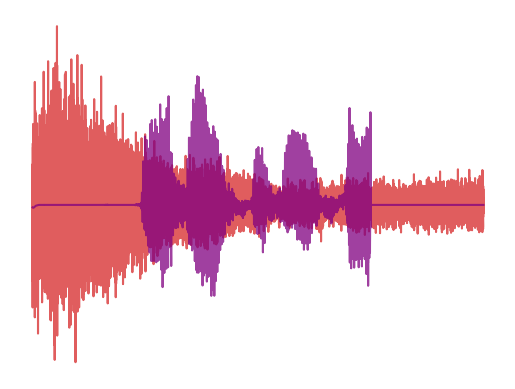

In [60]:
plt.plot(noise.squeeze(),'tab:red', alpha=0.75)
plt.plot(speech2.squeeze(), 'purple', alpha=0.75)
plt.axis('off')
# plt.savefig(outfig_dir/'speech2_noise_eg.png', transparent=True, dpi=500, bbox_inches='tight')


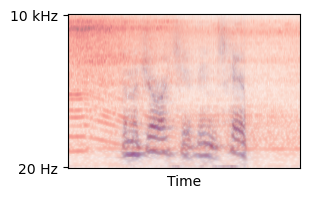

In [67]:
# coch_size = (3,2)


# plt.figure(figsize=coch_size)
# plt.imshow(noise_coch.squeeze().numpy(), aspect='auto', origin='lower', cmap='Reds');
# plt.imshow(speech2_coch.squeeze().numpy(), aspect='auto', origin='lower', cmap='Purples', alpha=0.5);

# # plt.ylabel('Frequency')
# plt.xlabel('Time')
# plt.xticks([])
# plt.yticks([1,210], ['20 Hz', '10 kHz'])
# plt.savefig(outfig_dir/'speech2_noise_coch_eg.png', transparent=True, dpi=500, bbox_inches='tight')


(np.float64(-1999.95),
 np.float64(41998.95),
 np.float64(-0.12993095479905606),
 np.float64(0.14577828757464886))

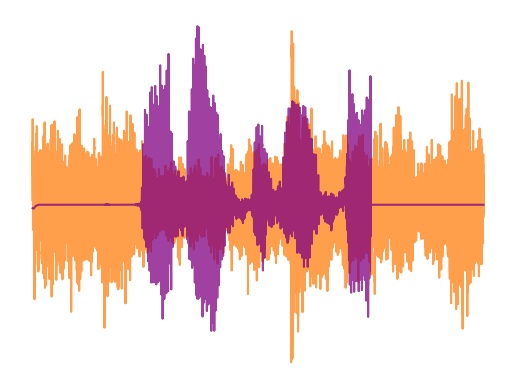

In [62]:
plt.plot(noise2.squeeze(),'tab:orange', alpha=0.75)
plt.plot(speech2.squeeze(), 'purple', alpha=0.75)
plt.axis('off')
# plt.savefig(outfig_dir/'speech2_noise2_eg.png', transparent=True, dpi=500, bbox_inches='tight')
#

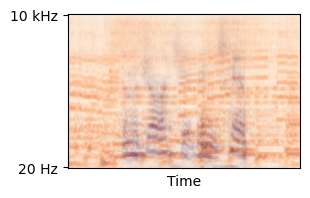

In [66]:
coch_size = (3,2)

# speech2_coch_for_plot = np.roll(speech2_coch.clone().numpy().squeeze(), 10000, axis=1)

plt.figure(figsize=coch_size)
plt.imshow(noise2_coch.squeeze().numpy(), aspect='auto', origin='lower', cmap='Oranges');
plt.imshow(speech2_coch.squeeze().numpy(), aspect='auto', origin='lower', cmap='Purples', alpha=0.5);

# plt.ylabel('Frequency')
plt.xlabel('Time')
plt.xticks([])
plt.yticks([1,210], ['20 Hz', '10 kHz'])
# plt.savefig(outfig_dir/'speech2_noise2_coch_eg.png', transparent=True, dpi=500, bbox_inches='tight')


([<matplotlib.axis.YTick at 0x15542f10abd0>,
 [Text(0, 1, '20 Hz'), Text(0, 210, '10 kHz')])

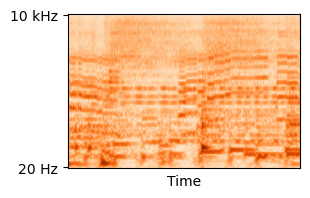

In [64]:
coch_size = (3,2)

# speech2_coch_for_plot = np.roll(speech2_coch.clone().numpy().squeeze(), 10000, axis=1)

plt.figure(figsize=coch_size)
plt.imshow(noise2_coch.squeeze().numpy(), aspect='auto', origin='lower', cmap='Oranges');

# plt.ylabel('Frequency')
plt.xlabel('Time')
plt.xticks([])
plt.yticks([1,210], ['20 Hz', '10 kHz'])
# plt.savefig(outfig_dir/'noise2_coch_eg.png', transparent=True, dpi=500, bbox_inches='tight')


([<matplotlib.axis.YTick at 0x1554482f8fe0>,
 [Text(0, 1, '20 Hz'), Text(0, 210, '10 kHz')])

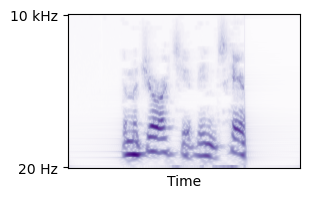

In [65]:
coch_size = (3,2)

# speech2_coch_for_plot = np.roll(speech2_coch.clone().numpy().squeeze(), 10000, axis=1)

plt.figure(figsize=coch_size)
plt.imshow(speech2_coch.squeeze().numpy(), aspect='auto', origin='lower', cmap='Purples');

# plt.ylabel('Frequency')
plt.xlabel('Time')
plt.xticks([])
plt.yticks([1,210], ['20 Hz', '10 kHz'])
# plt.savefig(outfig_dir/'speech2_coch_eg.png', transparent=True, dpi=500, bbox_inches='tight')
